# Section 2.2 — Impact Model Fitting
**Baseline:** OW (Obizhaeva-Wang, linear) + AFS (Alfonsi-Fruth-Schied, square-root) models, per-stock OLS, rolling monthly.
**Extension:** Non-parametric binned impact curve with cross-stock regularisation, gamma tuned on held-out month.

The transient impact half-life $H$ is **selected by grid search** over $H \in \{5, 10, 20, 30, 45, 60, 90, 120, 180\}$ minutes, choosing the value that maximises mean OOS $R^2$.  Since OW and AFS yield similar optima and the OOS $R^2$ curve is flat in that region, a single universal $H^*$ (midpoint of the two per-model optima) is adopted for all subsequent analysis.

Rolling 3-month windows (train / tune gamma / validate):

| Window | Train | Test (gamma) | Validate |
|--------|-------|----------|----------|
| 1 | Jan | Feb | Mar |
| 2 | Feb | Mar | Apr |
| ... | ... | ... | ... |
| 10 | Oct | Nov | Dec |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('data')
YEAR = '2019'

EXPL_HORIZON = 6          # 10-s periods (= 60 s)
STAT_COLS = ['xy', 'xx', 'yy', 'x', 'y', 'count']

H_GRID = [300, 600, 1200, 1800, 2700, 3600, 5400, 7200, 10800]
#          5m   10m   20m   30m   45m   60m   90m   2h    3h

MODEL_NAMES = {
    'linear': 'OW (Linear)',
    'sqrt':   'AFS (Square-Root)',
}

## 1 — Data Loading
We construct panel objects on a 10-second intraday grid for each stock-day pair.

Let $i$ index stocks, $d$ dates, and $t$ intraday bins.

- Signed traded flow: $q_{i,d,t}$ from `trade`
- Midprice proxy: $P_{i,d,t}$ from `midEnd`

We reshape into matrices with MultiIndex rows $(i,d)$ and time columns $t$:

- `traded_volume_df[(i,d), t] = q_{i,d,t}$
- `px_df[(i,d), t] = P_{i,d,t}$

Missing flow is set to zero ($q=0$), while missing prices are forward/back filled to keep return calculations well-defined.

In [2]:
traded_volume_dfs = []
px_dfs = []
stock_info_dfs = []

for month_int in range(1, 13):
    sys.stdout.write(f"\rLoading month {month_int:02d} ...")
    sys.stdout.flush()
    fname = DATA_DIR / f'bin{YEAR}{month_int:02d}.csv'
    raw = pd.read_csv(fname)

    tv = (raw[['stock', 'date', 'trade', 'time']]
          .pivot(index=['stock', 'date'], columns='time', values='trade')
          .fillna(0))
    px = (raw[['stock', 'date', 'midEnd', 'time']]
          .pivot(index=['stock', 'date'], columns='time', values='midEnd')
          .ffill(axis='columns').bfill(axis='columns'))

    traded_volume_dfs.append(tv)
    px_dfs.append(px)

    stock_info_dfs.append(pd.DataFrame({
        'px_vol': px.pct_change(1, axis='columns').std(axis='columns'),
        'volume': tv.abs().sum(axis='columns'),
    }).reset_index())

traded_volume_df = pd.concat(traded_volume_dfs, axis=0)
px_df = pd.concat(px_dfs, axis=0)
stock_info_df = pd.concat(stock_info_dfs).reset_index(drop=True)

print(f"\nLoaded: traded_volume_df {traded_volume_df.shape}, px_df {px_df.shape}")
print(f"Stocks: {traded_volume_df.index.get_level_values('stock').nunique()}")

Loading month 12 ...
Loaded: traded_volume_df (12402, 2341), px_df (12402, 2341)
Stocks: 50


## 2 — Daily Scaling Factors
For each stock-day $(i,d)$ we compute:

- Daily volume proxy:
  $$V_{i,d} = \sum_t |q_{i,d,t}|$$
- Intraday volatility proxy (10s returns):
  $$\sigma_{i,d} = \operatorname{std}_t\!\left(\frac{P_{i,d,t}-P_{i,d,t-1}}{P_{i,d,t-1}}\right)$$

These are used to normalize flow and express impact in volatility units. This makes coefficients comparable across stocks and days.

In [3]:
scaling_df = stock_info_df.copy()
monthly_scaling_factor = scaling_df.set_index(['stock', 'date']).loc[traded_volume_df.index]
print("monthly_scaling_factor shape:", monthly_scaling_factor.shape)
monthly_scaling_factor.head()

monthly_scaling_factor shape: (12402, 2)


px_vol    volume
stock date                          
A     2019-01-02  0.000383  217804.0
      2019-01-03  0.000527  485020.0
      2019-01-04  0.000366  244093.0
      2019-01-07  0.000359  251175.0
      2019-01-08  0.000364  181329.0

## 3 — Impact State and Regression Statistics (Theory)
The transient impact state follows an OW/AFS-style recursion on normalized flow:

$$\bar I_{t+1} = (1-\beta)\bar I_t + \tilde q_t, \qquad \beta = \frac{\ln 2}{H/10}$$

where $H$ is the half-life in seconds (selected by grid search) and each bin is 10 seconds.

Model-specific normalized flow:

- **OW linear:**
  $$\tilde q_t = \sigma\,\frac{q_t}{V}$$
- **AFS square-root:**
  $$\tilde q_t = \sigma\,\operatorname{sgn}(q_t)\sqrt{\left|\frac{q_t}{V}\right|}$$

For explanation horizon $\tau$ bins, define regression variables:

$$x_t = \bar I_t - \bar I_{t-\tau}, \qquad y_t = \frac{P_t-P_{t-\tau}}{P_{t-\tau}}$$

Then fit:

$$y_t = \alpha + \lambda x_t + \varepsilon_t$$

This is exactly the Exercise 3 specification with slope interpreted as the impact coefficient.

In [4]:
def impact_state(traded_volume_df, monthly_scaling_factor, half_life, model_type):
    """
    Normalised cumulative impact state (Ī_t / λ).
    Follows the course partial solutions (ewm with 1/(1-decay) rescaling).
    """
    space_kernels = {
        'linear': lambda x: x,
        'sqrt':   lambda x: np.sign(x) * np.sqrt(np.abs(x)),
    }
    beta = np.log(2) / (half_life / 10)
    decay_factor = np.exp(-beta)

    pre_ewm = traded_volume_df.copy()
    pre_ewm = pre_ewm.divide(monthly_scaling_factor['volume'], axis='rows')
    pre_ewm = space_kernels[model_type](pre_ewm)
    pre_ewm = pre_ewm.multiply(monthly_scaling_factor['px_vol'], axis='rows')
    pre_ewm.iloc[:, 1:] /= (1 - decay_factor)
    cum_impact = pre_ewm.T.ewm(alpha=1 - decay_factor, adjust=False).mean().T
    return cum_impact


def impact_regression_statistics(cum_impact, explanation_horizon_periods, px_df):
    """
    Build observation-level regression features and sufficient statistics.
    x = ΔĪ over the explanation horizon
    y = midprice return over the same horizon
    """
    impact_changes = (cum_impact
                      .diff(explanation_horizon_periods, axis='columns')
                      .T.unstack())
    reg_stat_df = (impact_changes
                   .reset_index()
                   .rename({'level_2': 'time', 0: 'x'}, axis='columns'))

    returns = (px_df
               .pct_change(explanation_horizon_periods, axis='columns')
               .T.unstack()
               .reset_index()
               .rename({'level_2': 'time', 0: 'y'}, axis='columns'))

    reg_stat_df = reg_stat_df.loc[reg_stat_df['time'] >= '10:00:00'].dropna(axis=0).copy()
    reg_stat_df['y']     = returns['y']
    reg_stat_df['xy']    = reg_stat_df['x'] * reg_stat_df['y']
    reg_stat_df['xx']    = reg_stat_df['x'] ** 2
    reg_stat_df['yy']    = reg_stat_df['y'] ** 2
    reg_stat_df['count'] = 1
    return reg_stat_df

print("Functions defined.")

Functions defined.


## 4 — Daily Sufficient Statistics
For computational efficiency, we precompute daily sufficient statistics and aggregate later by month.

Given observations $(x_t, y_t)$ for each stock-day, define:

$$S_x=\sum_t x_t,\; S_y=\sum_t y_t,\; S_{xx}=\sum_t x_t^2,\; S_{yy}=\sum_t y_t^2,\; S_{xy}=\sum_t x_t y_t,\; n=\sum_t 1$$

These summaries are additive across days, enabling fast rolling-window estimation without rerunning bin-level regressions each time.

**Note:** Impact states and sufficient statistics are computed inside the half-life grid search (Section 5b) and baseline estimation below; no separate precomputation step is needed.

In [5]:
pass

## 5 — Regression Helpers (Theory)
Using sufficient stats, OLS estimates are:

$$\hat\lambda = \frac{S_{xy} - S_x S_y/n}{S_{xx} - S_x^2/n}, \qquad \hat\alpha = S_y/n - \hat\lambda\,S_x/n$$

Define total variation and residual variation:

$$SS_{\text{tot}} = S_{yy} - S_y^2/n$$
$$SS_{\text{res}}(\alpha,\lambda) = \sum_t (y_t-\alpha-\lambda x_t)^2$$

Then:

$$R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}$$

All of these can be evaluated directly from $(S_x,S_y,S_{xx},S_{yy},S_{xy},n)$.

In [6]:
def ols_from_sums(s):
    """OLS slope (beta/lambda) and intercept (alpha) from sufficient-stat sums."""
    n = s['count']
    cov_xy = s['xy'] - s['x'] * s['y'] / n
    var_x  = s['xx'] - s['x'] ** 2 / n
    beta  = cov_xy / var_x
    alpha = s['y'] / n - beta * s['x'] / n
    return beta, alpha


def r2_from_sums(s, beta, alpha):
    """R² computed from sufficient stats and given (beta, alpha)."""
    n = s['count']
    ss_tot = s['yy'] - s['y'] ** 2 / n
    ss_res = (s['yy']
              - 2 * beta  * s['xy']
              - 2 * alpha * s['y']
              + 2 * alpha * beta * s['x']
              + beta ** 2 * s['xx']
              + alpha ** 2 * n)
    return 1 - ss_res / ss_tot


def mse_from_sums(s, beta, alpha):
    """Total squared residual from sufficient stats."""
    n = s['count']
    return (s['yy']
            - 2 * beta  * s['xy']
            - 2 * alpha * s['y']
            + 2 * alpha * beta * s['x']
            + beta ** 2 * s['xx']
            + alpha ** 2 * n)


print("Helpers defined.")


Helpers defined.


## 5b — Half-Life Grid Search
Rather than prescribing a fixed half-life $H$, we select $H^*$ empirically by maximising mean OOS $R^2$ over a grid $\mathcal{H}=\{5,10,20,30,45,60,90,120,180\}$ minutes.

For each candidate $H$ and model type:
1. Recompute impact states $\bar I_t(H)$
2. Build daily sufficient statistics
3. Run the rolling OLS over 10 windows
4. Record mean OOS $R^2$ across all stocks and windows

The grid search is run independently for OW and AFS.  Since the two optima are close and the OOS $R^2$ curve is essentially flat in that region, we adopt a single universal half-life equal to the midpoint of the two per-model optima.  This is appropriate because $H$ governs the rate at which the market absorbs past order flow — a property of the market, not of the functional form assumed for impact.

  Grid search: AFS (Square-Root), H=180 min ...
=== Mean OOS R² by half-life (minutes) ===
model    linear    sqrt
5 min    0.1440  0.2373
10 min   0.1530  0.2525
20 min   0.1569  0.2590
30 min   0.1579  0.2604
45 min   0.1582  0.2609
60 min   0.1583  0.2608
90 min   0.1581  0.2602
120 min  0.1578  0.2595
180 min  0.1573  0.2583

OW (Linear): H* = 60 min (3600 s), OOS R² = 0.1583

AFS (Square-Root): H* = 45 min (2700 s), OOS R² = 0.2609


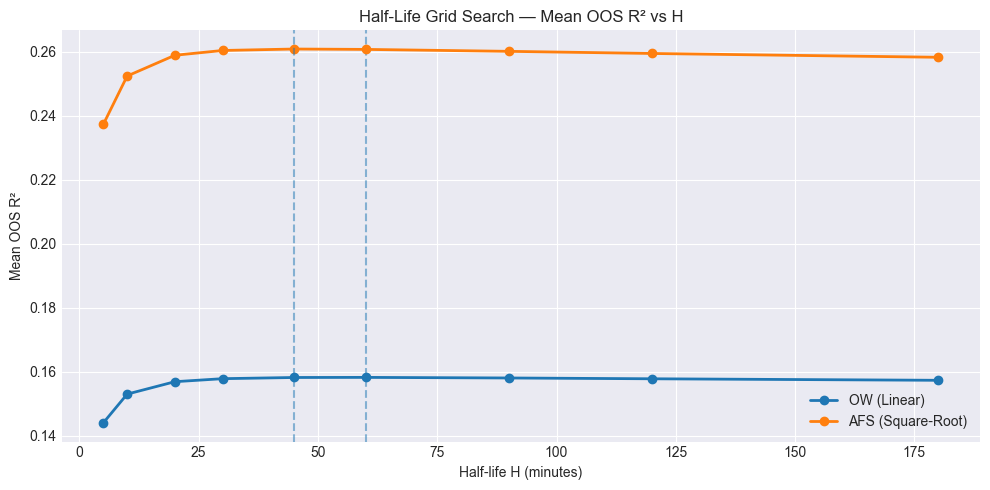

Computing final impact states for OW (Linear) (H*=60 min) ...
  OW (Linear): 12,352 (stock, date) rows
Computing final impact states for AFS (Square-Root) (H*=45 min) ...
  AFS (Square-Root): 12,352 (stock, date) rows
Done.


In [7]:
grid_records = []

for model_type in ['linear', 'sqrt']:
    for H in H_GRID:
        sys.stdout.write(f"\r  Grid search: {MODEL_NAMES[model_type]}, H={H/60:.0f} min ...")
        sys.stdout.flush()

        cum_impact = impact_state(traded_volume_df, monthly_scaling_factor, H, model_type)
        reg_stat_df = impact_regression_statistics(cum_impact, EXPL_HORIZON, px_df)

        summary = (reg_stat_df
                   .groupby(['stock', 'date'])[STAT_COLS]
                   .sum()
                   .reset_index())
        summary = summary.loc[summary['yy'] > 1e-12].copy()
        summary['date'] = pd.to_datetime(summary['date'])
        summary['month'] = summary['date'].dt.month

        for train_month in range(1, 11):
            val_month = train_month + 2
            train = summary.loc[summary['month'] == train_month].groupby('stock')[STAT_COLS].sum()
            val   = summary.loc[summary['month'] == val_month].groupby('stock')[STAT_COLS].sum()
            common = train.index.intersection(val.index)
            if len(common) == 0:
                continue
            betas, alphas = ols_from_sums(train.loc[common])
            oos_r2 = r2_from_sums(val.loc[common], betas, alphas)

            for stock in common:
                grid_records.append({
                    'model': model_type, 'H': H,
                    'train_month': train_month, 'stock': stock,
                    'lambda': betas[stock], 'oos_r2': oos_r2[stock],
                })

grid_df = pd.DataFrame(grid_records)

pivot = grid_df.groupby(['model', 'H'])['oos_r2'].mean().unstack('model')
print("\n=== Mean OOS R² by half-life (minutes) ===")
pivot.index = [f"{int(h/60)} min" for h in pivot.index]
print(pivot.round(4).to_string())

best_per_model = {}
for mt in ['linear', 'sqrt']:
    sub = grid_df.loc[grid_df['model'] == mt].groupby('H')['oos_r2'].mean()
    best_per_model[mt] = int(sub.idxmax())
    print(f"\n{MODEL_NAMES[mt]}: H* = {best_per_model[mt]/60:.0f} min ({best_per_model[mt]} s), "
          f"OOS R² = {sub.max():.4f}")

HALF_LIFE = int(np.mean(list(best_per_model.values())))
print(f"\nAdopted universal H* = {HALF_LIFE/60:.1f} min ({HALF_LIFE} s)  "
      f"(midpoint of per-model optima; OOS R² is flat in this region)")

fig, ax = plt.subplots(figsize=(10, 5))
for mt in ['linear', 'sqrt']:
    sub = grid_df.loc[grid_df['model'] == mt].groupby('H')['oos_r2'].mean()
    ax.plot([h/60 for h in sub.index], sub.values, 'o-', lw=2, label=MODEL_NAMES[mt])
    ax.axvline(best_per_model[mt]/60, ls=':', alpha=0.4,
               color='grey')
ax.axvline(HALF_LIFE/60, ls='--', lw=2, color='black', label=f'Universal H* = {HALF_LIFE/60:.1f} min')
ax.set_xlabel('Half-life H (minutes)')
ax.set_ylabel('Mean OOS R²')
ax.set_title('Half-Life Grid Search — Mean OOS R² vs H')
ax.legend()
plt.tight_layout()
plt.show()

summary_dfs = {}
for model_type in ['linear', 'sqrt']:
    print(f"Computing final impact states for {MODEL_NAMES[model_type]} (H*={HALF_LIFE/60:.1f} min) ...")
    cum_impact = impact_state(traded_volume_df, monthly_scaling_factor, HALF_LIFE, model_type)
    reg_stat_df = impact_regression_statistics(cum_impact, EXPL_HORIZON, px_df)
    summary = (reg_stat_df
               .groupby(['stock', 'date'])[STAT_COLS]
               .sum()
               .reset_index())
    summary = summary.loc[summary['yy'] > 1e-12].copy()
    summary['date'] = pd.to_datetime(summary['date'])
    summary['month'] = summary['date'].dt.month
    summary_dfs[model_type] = summary
    print(f"  {MODEL_NAMES[model_type]}: {len(summary):,} (stock, date) rows")
print("Done.")

## 6 — Baseline Rolling Estimation (Theory)
For each rolling window $m=1,\dots,10$:

- Train month: $m$
- Validation month: $m+2$

Per stock $i$, estimate $(\hat\alpha_i,\hat\lambda_i)$ from month $m$ using OLS. Then score out-of-sample on month $m+2$:

$$R^2_{\text{OOS},i} = 1 - \frac{\sum_{t\in m+2}(y_{i,t}-\hat\alpha_i-\hat\lambda_i x_{i,t})^2}{\sum_{t\in m+2}(y_{i,t}-\bar y_{i,m+2})^2}$$

This evaluates whether fitted impact parameters generalize two months ahead.

In [8]:
baseline_records = []

for model_type in ['linear', 'sqrt']:
    sdf = summary_dfs[model_type]
    for train_month in range(1, 11):
        val_month = train_month + 2

        train = sdf.loc[sdf['month'] == train_month].groupby('stock')[STAT_COLS].sum()
        val   = sdf.loc[sdf['month'] == val_month].groupby('stock')[STAT_COLS].sum()
        common = train.index.intersection(val.index)
        train, val = train.loc[common], val.loc[common]

        betas, alphas = ols_from_sums(train)
        is_r2  = r2_from_sums(train, betas, alphas)
        oos_r2 = r2_from_sums(val,   betas, alphas)

        for stock in common:
            baseline_records.append({
                'model': model_type,
                'train_month': train_month,
                'val_month': val_month,
                'stock': stock,
                'lambda': betas[stock],
                'alpha':  alphas[stock],
                'is_r2':  is_r2[stock],
                'oos_r2': oos_r2[stock],
            })

baseline_df = pd.DataFrame(baseline_records)
print(f"Baseline results: {len(baseline_df):,} rows")

for mt in ['linear', 'sqrt']:
    sub = baseline_df.loc[baseline_df['model'] == mt]
    print(f"\n{MODEL_NAMES[mt]} — Mean λ: {sub['lambda'].mean():.2f}, "
          f"Mean IS R²: {sub['is_r2'].mean():.4f}, "
          f"Mean OOS R²: {sub['oos_r2'].mean():.4f}")

Baseline results: 992 rows

OW (Linear) — Mean λ: 313.05, Mean IS R²: 0.1732, Mean OOS R²: 0.1583

AFS (Square-Root) — Mean λ: 20.27, Mean IS R²: 0.2651, Mean OOS R²: 0.2609


### Per-stock summary over windows
This table reports, for each stock and model, averages over rolling windows:

$$\bar\lambda_i=\frac{1}{W}\sum_{w=1}^{W}\hat\lambda_{i,w},\quad
\overline{R^2_{\text{IS},i}}=\frac{1}{W}\sum_{w=1}^{W}R^2_{\text{IS},i,w},\quad
\overline{R^2_{\text{OOS},i}}=\frac{1}{W}\sum_{w=1}^{W}R^2_{\text{OOS},i,w}$$

This helps compare cross-sectional stability and predictability.

In [9]:
# Per-stock average across all windows
pivot = (baseline_df
         .groupby(['model', 'stock'])[['lambda', 'is_r2', 'oos_r2']]
         .mean()
         .round(4))
print(f"=== {MODEL_NAMES['linear']} ===")
print(pivot.loc['linear'].to_string())
print(f"\n=== {MODEL_NAMES['sqrt']} ===")
print(pivot.loc['sqrt'].to_string())

=== OW (Linear) ===
         lambda   is_r2  oos_r2
stock                          
A      323.5992  0.1503  0.1375
AAL    275.0318  0.1702  0.1461
AAP    324.4953  0.2101  0.1839
AAPL   423.7000  0.2463  0.2180
ABBV   359.6857  0.1580  0.1534
ABC    310.6880  0.1744  0.1613
ABMD   257.8270  0.1878  0.1807
ABT    351.1956  0.1441  0.1360
ACN    360.7723  0.1600  0.1525
ADBE   347.5907  0.1366  0.1281
ADI    293.1899  0.1153  0.0963
ADM    353.5571  0.2139  0.2024
ADP    296.9027  0.1298  0.1155
ADS    286.1452  0.2068  0.2033
ADSK   331.3732  0.1494  0.1398
AEE    325.4275  0.1596  0.1589
AEP    278.7238  0.1269  0.1173
AES    220.2767  0.2117  0.2156
AFL    390.5804  0.2104  0.1373
AGN    292.1390  0.1294  0.1041
AIG    366.6023  0.1714  0.1537
AIV    277.5681  0.1751  0.1653
AIZ    259.4360  0.1929  0.1763
AJG    319.4796  0.1858  0.1768
AKAM   279.0288  0.1361  0.0978
ALB    321.3517  0.1792  0.1640
ALGN   214.9096  0.1273  0.0787
ALK    310.2118  0.1913  0.1790
ALL    347.8515  0.1

## 7  Non-Parametric Extension
Instead of assuming a parametric form $y = \alpha + \lambda x$, we estimate the impact function $g(x)$ directly.

### Binned estimator

Partition the regressor $x = \Delta\bar I$ into $B$ quantile bins $\{b_1,\dots,b_B\}$ computed on the **training month** data (pooled across all stocks).

For each stock $i$ and bin $b$, define the per-stock bin estimate:

$$\hat g_{i,b} = \frac{1}{n_{i,b}}\sum_{t:\,x_t\in b} y_t$$

and the universal (pooled) bin estimate:

$$\bar g_b = \frac{1}{\sum_i n_{i,b}}\sum_i \sum_{t:\,x_t\in b} y_t$$

### Regularisation toward the universal curve

For each stock $i$ and bin $b$, solve:

$$\min_{g_{i,b}}\;\sum_{t:\,x_t\in b}(y_t - g_{i,b})^2 + \gamma\,(g_{i,b}-\bar g_b)^2$$

Closed form:

$$g_{i,b}^{\text{reg}}(\gamma) = \frac{n_{i,b}\,\hat g_{i,b} + \gamma\,\bar g_b}{n_{i,b}+\gamma} = \frac{S_{y,i,b}+\gamma\,\bar g_b}{n_{i,b}+\gamma}$$

### Tuning $\gamma$

- Train bins + estimates on month $m$
- For each $\gamma$, predict on test month $m+1$: assign each test observation to its bin, predict $\hat y = g_{i,b}^{\text{reg}}(\gamma)$
- Pick $\gamma^* = \arg\min_\gamma \text{MSE}_{\text{test}}$
- Validate OOS $R^2$ on month $m+2$

### Prediction and $R^2$

Given a new observation $x_t$, find its bin $b(x_t)$ and predict $\hat y_t = g_{i,b(x_t)}^{\text{reg}}$.

$$R^2_{\text{OOS}} = 1 - \frac{\sum_t (y_t - \hat y_t)^2}{\sum_t (y_t - \bar y)^2}$$

In [10]:
N_BINS = 15

def build_bin_stats(reg_stat_df, month, bin_edges=None):
    mdf = reg_stat_df.loc[reg_stat_df['month'] == month].copy()

    if bin_edges is None:
        bin_edges = np.quantile(mdf['x'].dropna(), np.linspace(0, 1, N_BINS + 1))
        bin_edges[0]  = -np.inf
        bin_edges[-1] =  np.inf

    mdf['bin'] = pd.cut(mdf['x'], bins=bin_edges, labels=False, include_lowest=True)
    mdf = mdf.dropna(subset=['bin'])
    mdf['bin'] = mdf['bin'].astype(int)

    stats = (mdf.groupby(['stock', 'bin'])
                .agg(sy=('y', 'sum'), syy=('y', lambda v: (v**2).sum()),
                     n=('y', 'count'))
                .reset_index())
    stats['mean_y'] = stats['sy'] / stats['n']
    return stats, bin_edges


def universal_bin_means(train_stats):
    pooled = train_stats.groupby('bin')[['sy', 'n']].sum()
    pooled['g_bar'] = pooled['sy'] / pooled['n']
    return pooled['g_bar']


def regularised_bin_means(train_stats, g_bar, gamma):
    merged = train_stats.merge(g_bar.rename('g_bar'), on='bin', how='left')
    merged['g_reg'] = (merged['sy'] + gamma * merged['g_bar']) / (merged['n'] + gamma)
    return merged


def predict_and_score(test_stats, g_reg_lookup):
    merged = test_stats.merge(g_reg_lookup[['stock', 'bin', 'g_reg']],
                              on=['stock', 'bin'], how='inner')
    ss_res = (merged['syy']
              - 2 * merged['g_reg'] * merged['sy']
              + merged['g_reg']**2 * merged['n'])

    total_n  = merged['n'].sum()
    total_sy = merged['sy'].sum()
    total_syy = merged['syy'].sum()
    y_bar = total_sy / total_n
    ss_tot = total_syy - total_n * y_bar**2

    total_ss_res = ss_res.sum()
    r2 = 1 - total_ss_res / ss_tot if ss_tot > 0 else np.nan
    mse = total_ss_res / total_n
    return mse, r2

print("Non-parametric helpers defined.")

Non-parametric helpers defined.


### Precompute observation-level data with month labels
We need the raw $(x_t, y_t)$ observations (not just daily sums) to assign them to quantile bins.

In [11]:
obs_dfs = {}

for model_type in ['linear', 'sqrt']:
    print(f"Building observation-level data for {MODEL_NAMES[model_type]} (H*={HALF_LIFE/60:.1f} min) ...")
    cum_impact = impact_state(traded_volume_df, monthly_scaling_factor,
                              HALF_LIFE, model_type)
    reg_stat_df = impact_regression_statistics(cum_impact, EXPL_HORIZON, px_df)

    reg_stat_df['date'] = pd.to_datetime(reg_stat_df['date'])
    reg_stat_df['month'] = reg_stat_df['date'].dt.month
    obs_dfs[model_type] = reg_stat_df[['stock', 'date', 'month', 'x', 'y']].copy()
    print(f"  {MODEL_NAMES[model_type]}: {len(obs_dfs[model_type]):,} observations")

print("Done.")

Building observation-level data for OW (Linear) (H*=60 min) ...
  OW (Linear): 26,800,722 observations
Building observation-level data for AFS (Square-Root) (H*=45 min) ...
  AFS (Square-Root): 26,800,722 observations
Done.


### Rolling non-parametric estimation
For each window $(m, m+1, m+2)$:
1. Compute quantile bin edges from training month $m$ (pooled)
2. Build per-stock and universal bin means on month $m$
3. Tune $\gamma$ on test month $m+1$ (adaptive grid scaled to median bin count)
4. Validate OOS $R^2$ on month $m+2$

In [ ]:
np_records = []
np_tuning_curves = {}
np_curves = {}

for model_type in ['linear', 'sqrt']:
    odf = obs_dfs[model_type]

    for train_month in range(1, 11):
        test_month = train_month + 1
        val_month  = train_month + 2

        train_stats, bin_edges = build_bin_stats(odf, train_month, bin_edges=None)
        test_stats, _          = build_bin_stats(odf, test_month,  bin_edges=bin_edges)
        val_stats, _           = build_bin_stats(odf, val_month,   bin_edges=bin_edges)

        g_bar = universal_bin_means(train_stats)

        median_n = train_stats['n'].median()
        gamma_grid = median_n * np.logspace(-3, 3, 60)

        best_gamma, best_mse = None, np.inf
        gamma_mses = []

        for gamma in gamma_grid:
            reg_df_g = regularised_bin_means(train_stats, g_bar, gamma)
            mse, _ = predict_and_score(test_stats, reg_df_g)
            gamma_mses.append(float(mse))
            if mse < best_mse:
                best_mse = mse
                best_gamma = gamma

        np_tuning_curves[(model_type, train_month)] = (gamma_grid, gamma_mses)

        reg_best = regularised_bin_means(train_stats, g_bar, best_gamma)
        _, oos_r2_reg = predict_and_score(val_stats, reg_best)

        raw = regularised_bin_means(train_stats, g_bar, 0.0)
        _, oos_r2_raw = predict_and_score(val_stats, raw)

        univ = regularised_bin_means(train_stats, g_bar, 1e15)
        _, oos_r2_univ = predict_and_score(val_stats, univ)

        np_records.append({
            'model': model_type,
            'train_month': train_month,
            'best_gamma': best_gamma,
            'median_n': median_n,
            'oos_r2_raw': oos_r2_raw,
            'oos_r2_univ': oos_r2_univ,
            'oos_r2_reg': oos_r2_reg,
        })

        if train_month == 3:
            np_curves[(model_type, 'train')] = train_stats.copy()
            np_curves[(model_type, 'g_bar')] = g_bar.copy()
            np_curves[(model_type, 'reg_best')] = reg_best.copy()
            np_curves[(model_type, 'bin_edges')] = bin_edges

np_results = pd.DataFrame(np_records)
print(f"Non-parametric results: {len(np_results)} rows")

for mt in ['linear', 'sqrt']:
    sub = np_results.loc[np_results['model'] == mt]
    print(f"\n{MODEL_NAMES[mt]}:")
    print(f"  Mean OOS R2 (per-stock raw):   {sub['oos_r2_raw'].mean():.5f}")
    print(f"  Mean OOS R2 (universal):       {sub['oos_r2_univ'].mean():.5f}")
    print(f"  Mean OOS R2 (regularised):     {sub['oos_r2_reg'].mean():.5f}")
    print(f"  Median best gamma:             {sub['best_gamma'].median():.1f}")
    print(f"  Median bin count:              {sub['median_n'].median():.0f}")

Non-parametric results: 20 rows

OW (Linear):
  Mean OOS R2 (per-stock raw):   0.22053
  Mean OOS R2 (universal):       0.21155
  Mean OOS R2 (regularised):     0.22099
  Median best gamma:             495.0
  Median bin count:              3070

AFS (Square-Root):
  Mean OOS R2 (per-stock raw):   0.26237
  Mean OOS R2 (universal):       0.25766
  Mean OOS R2 (regularised):     0.26277
  Median best gamma:             449.5
  Median bin count:              3042


## 8 — Results and Diagnostics (Theory)
We compare three estimators per model family:

- **Per-stock bins** ($\gamma=0$): each stock has its own curve
- **Universal bins** ($\gamma\to\infty$): single pooled curve for all stocks
- **Regularised bins**: per-stock curves shrunk toward universal

Key diagnostics:
- OOS $R^2$ comparison across windows
- $\gamma$ tuning curve (MSE vs $\gamma$)
- Estimated impact curves $g(x)$

In [ ]:
summary_table = (np_results
    .groupby('model')[['oos_r2_raw', 'oos_r2_univ', 'oos_r2_reg']]
    .mean()
    .rename(columns={
        'oos_r2_raw':  'Per-Stock Bins',
        'oos_r2_univ': 'Universal Bins',
        'oos_r2_reg':  'Regularised Bins',
    }))
print("=== Mean OOS R2 (averaged over all windows) ===")
print(summary_table.round(5).to_string())

print(f"\n=== Mean OOS R2 by rolling window -- {MODEL_NAMES['linear']} ===")
window_summary = (np_results.loc[np_results['model'] == 'linear']
    [['train_month', 'oos_r2_raw', 'oos_r2_univ', 'oos_r2_reg', 'best_gamma']])
window_summary.index = [f"Win {int(r.train_month)} (train={int(r.train_month)}, val={int(r.train_month)+2})"
                        for _, r in window_summary.iterrows()]
print(window_summary[['oos_r2_raw', 'oos_r2_univ', 'oos_r2_reg']].round(5).to_string())

=== Mean OOS R2 (averaged over all windows) ===
        Per-Stock Bins  Universal Bins  Regularised Bins
model                                                   
linear         0.22053         0.21155           0.22099
sqrt           0.26237         0.25766           0.26277

=== Mean OOS R2 by rolling window -- OW (Linear) ===
                           oos_r2_raw  oos_r2_univ  oos_r2_reg
Win 1 (train=1, val=3)        0.22702      0.22010     0.22918
Win 2 (train=2, val=4)        0.23720      0.23036     0.23739
Win 3 (train=3, val=5)        0.21654      0.21004     0.21730
Win 4 (train=4, val=6)        0.23516      0.22782     0.23558
Win 5 (train=5, val=7)        0.22486      0.21925     0.22537
Win 6 (train=6, val=8)        0.20144      0.19266     0.20150
Win 7 (train=7, val=9)        0.20595      0.19763     0.20602
Win 8 (train=8, val=10)       0.20440      0.19414     0.20467
Win 9 (train=9, val=11)       0.22568      0.21272     0.22572
Win 10 (train=10, val=12)     0.22705   

### Hyperparameter tuning curve
$$\text{MSE}_{\text{test}}(\gamma) = \frac{1}{N_{\text{obs}}}\sum_{i,b} \left(S_{yy,i,b} - 2g_{i,b}^{\text{reg}}(\gamma)S_{y,i,b} + g_{i,b}^{\text{reg}}(\gamma)^2 n_{i,b}\right)$$

A U-shaped or decreasing curve indicates meaningful bias-variance tradeoff.

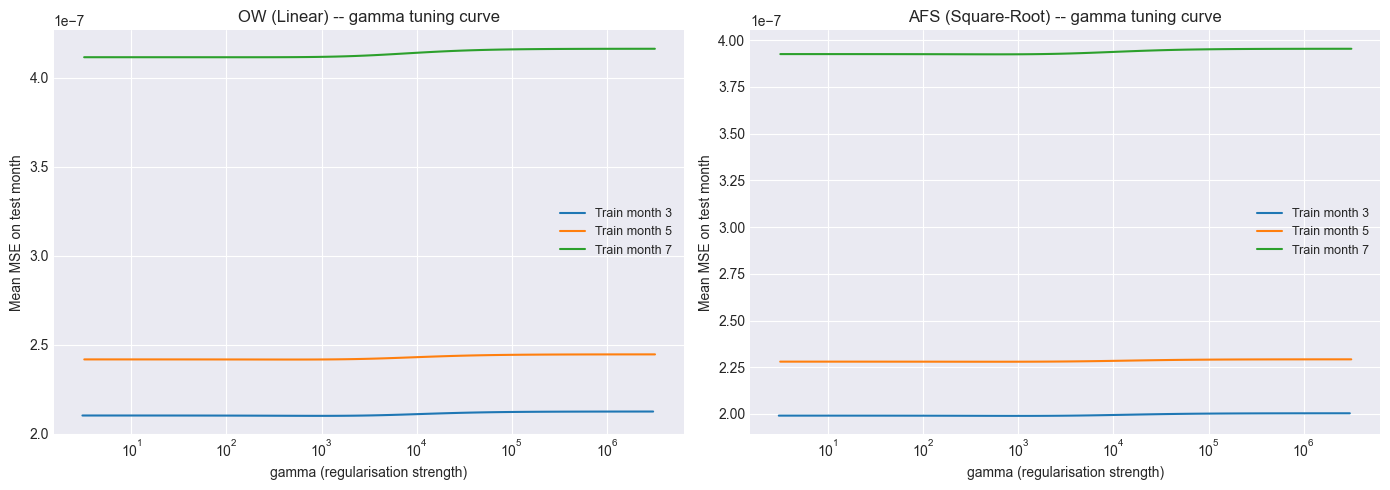

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mt in zip(axes, ['linear', 'sqrt']):
    for tw in [3, 5, 7]:
        key = (mt, tw)
        if key in np_tuning_curves:
            grid, mses = np_tuning_curves[key]
            ax.plot(grid, mses, label=f'Train month {tw}')
    ax.set_xscale('log')
    ax.set_xlabel('gamma (regularisation strength)')
    ax.set_ylabel('Mean MSE on test month')
    ax.set_title(f'{MODEL_NAMES[mt]} -- gamma tuning curve')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Estimated impact curves
The non-parametric impact curve $g(x)$ per stock and the universal curve $\bar g(x)$, for a representative window (train month = 3).

If the data-driven shape is roughly linear, OW is validated; if concave, AFS is supported.

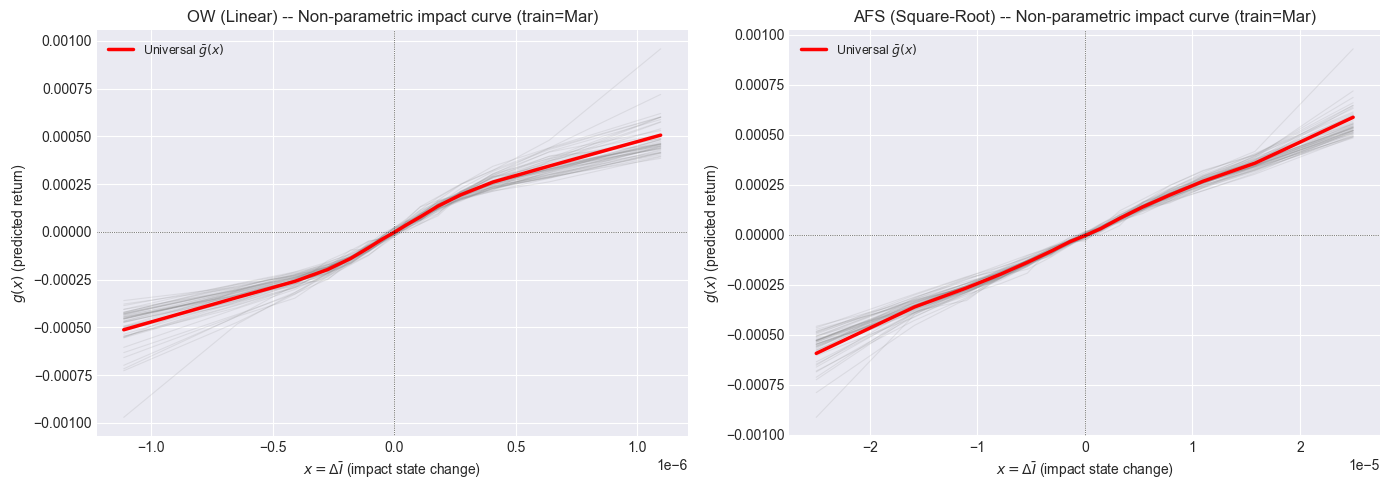

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mt in zip(axes, ['linear', 'sqrt']):
    train_s = np_curves[(mt, 'train')]
    g_bar   = np_curves[(mt, 'g_bar')]
    reg_b   = np_curves[(mt, 'reg_best')]
    edges   = np_curves[(mt, 'bin_edges')]

    bin_centers = 0.5 * (edges[:-1] + edges[1:])
    bin_centers[0]  = edges[1]  - (edges[2] - edges[1])
    bin_centers[-1] = edges[-2] + (edges[-2] - edges[-3])

    for stock in train_s['stock'].unique():
        s = reg_b.loc[reg_b['stock'] == stock].sort_values('bin')
        if len(s) == len(bin_centers):
            ax.plot(bin_centers, s['g_reg'].values, color='grey', alpha=0.15, lw=0.8)

    g_bar_sorted = g_bar.sort_index()
    ax.plot(bin_centers[:len(g_bar_sorted)], g_bar_sorted.values,
            color='red', lw=2.5, label='Universal $\\bar g(x)$')

    ax.axhline(0, color='black', ls=':', lw=0.5)
    ax.axvline(0, color='black', ls=':', lw=0.5)
    ax.set_xlabel('$x = \\Delta\\bar I$ (impact state change)')
    ax.set_ylabel('$g(x)$ (predicted return)')
    ax.set_title(f'{MODEL_NAMES[mt]} -- Non-parametric impact curve (train=Mar)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### OOS $R^2$: Parametric vs Non-Parametric
Compare the parametric baseline (per-stock OLS from Section 6) with the non-parametric binned estimator.

=== OOS R2 Comparison (averaged over all windows) ===
        Parametric OLS  NP Per-Stock  NP Regularised
model                                               
linear         0.15826       0.22053         0.22099
sqrt           0.26090       0.26237         0.26277


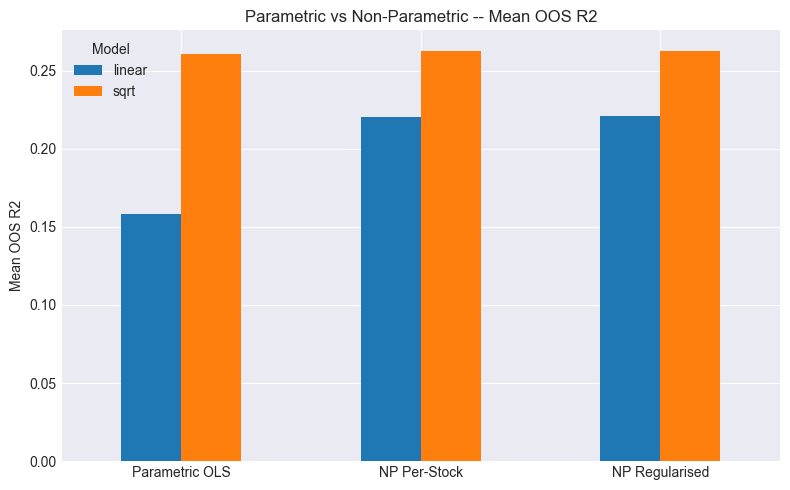

In [ ]:
param_avg = (baseline_df
    .groupby('model')[['oos_r2']]
    .mean()
    .rename(columns={'oos_r2': 'Parametric OLS'}))

nonparam_avg = (np_results
    .groupby('model')[['oos_r2_raw', 'oos_r2_reg']]
    .mean()
    .rename(columns={'oos_r2_raw': 'NP Per-Stock', 'oos_r2_reg': 'NP Regularised'}))

comparison = param_avg.join(nonparam_avg)
print("=== OOS R2 Comparison (averaged over all windows) ===")
print(comparison.round(5).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
comparison.T.plot(kind='bar', ax=ax, rot=0)
ax.set_ylabel('Mean OOS R2')
ax.set_title('Parametric vs Non-Parametric -- Mean OOS R2')
ax.legend(title='Model')
plt.tight_layout()
plt.show()

## Summary

| Component | Description |
|-----------|-------------|
| **Half-life selection** | Grid search over $\{5,10,\ldots,180\}$ min per model family; single universal $H^*$ adopted as midpoint of OW/AFS optima (OOS $R^2$ flat in that region) |
| **Baseline** | Per-stock OLS $\lambda$ for both OW (Obizhaeva-Wang, linear) and AFS (Alfonsi-Fruth-Schied, square-root), rolling 10-window |
| **Non-parametric extension** | Binned impact curve $g_{i,b}$: no functional form assumed |
| **Universal curve** | Pooled $\bar g_b$ across all 50 stocks per training month |
| **Regularisation** | Per-stock bin means shrunk toward $\bar g_b$ via $\gamma(g_{i,b}-\bar g_b)^2$ penalty |
| **$\gamma$ tuning** | Adaptive grid scaled to median bin count; tuned on test month $(m+1)$ |
| **3-sample split** | Train (month $m$) / Tune-$\gamma$ (month $m+1$) / Validate (month $m+2$) |